In [62]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV ,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
if 'ID' in df.columns:
    df = df.drop('ID',axis=1)
targer_col = 'Reached.on.Time_Y.N'
x = df.drop(targer_col, axis =1)
y = df[targer_col]

print(f"Features Shape: {x.head()}")
print(f"Target Shape: {y.tail()}")

Features Shape:   Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0               D           Flight                    4                2   
1               F           Flight                    4                5   
2               A           Flight                    2                2   
3               B           Flight                    3                3   
4               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  
0                44           1233  
1                59           3088  
2

In [4]:
x.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,D,Flight,4,2,177,3,low,F,44,1233
1,F,Flight,4,5,216,2,low,M,59,3088
2,A,Flight,2,2,183,4,low,M,48,3374
3,B,Flight,3,3,176,4,medium,M,10,1177
4,C,Flight,2,2,184,3,medium,F,46,2484


In [5]:
importance_mapping={
    'low':1,
    'medium':2,
    'high':3
}

In [6]:
x['Product_importance']=x['Product_importance'].map(importance_mapping)

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
x['Gender'] = encoder.fit_transform(
    x['Gender'])

In [10]:
cat_cols = x.select_dtypes(include=['object']).columns
num_cols = x.select_dtypes(exclude=['object']).columns

In [13]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [14]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=30)


In [15]:
pipe_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Accuracy: 0.6245454545454545
              precision    recall  f1-score   support

           0       0.53      0.56      0.54       874
           1       0.70      0.66      0.68      1326

    accuracy                           0.62      2200
   macro avg       0.61      0.61      0.61      2200
weighted avg       0.63      0.62      0.63      2200



Confusion Matrix:
 [[493 381]
 [445 881]]


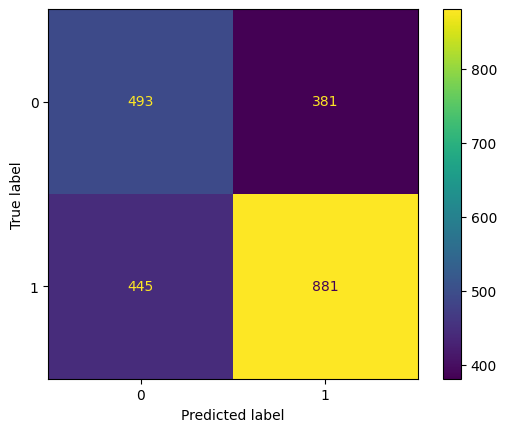

In [61]:
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [31]:
param_dist = {
    'model__C': np.logspace(-4, 4, 20),
    'model__solver': ['lbfgs', 'liblinear'],  # safe combo
    'model__max_iter': [500, 1000, 2000]
}

In [92]:
search_lr = RandomizedSearchCV(
    pipe_lr,              # your pipeline
    param_distributions=param_dist,
    n_iter=10,            # 🔥 only try 10 random combinations
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [93]:
search_lr.fit(X_train, y_train)

print("Best Params:", search_lr.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'model__solver': 'lbfgs', 'model__max_iter': 1000, 'model__C': 0.004832930238571752}


In [95]:
y_pred_lr_tuned = search_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6313636363636363


Confusion Matrix:
 [[465 409]
 [403 923]]


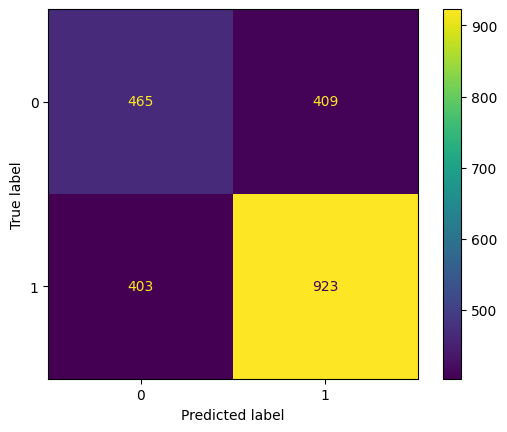

In [96]:
cm = confusion_matrix(y_test, y_pred_lr_tuned)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [67]:
pipe_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.6604545454545454
              precision    recall  f1-score   support

           0       0.56      0.72      0.63       874
           1       0.77      0.62      0.69      1326

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.66      2200



Confusion Matrix:
 [[626 248]
 [499 827]]


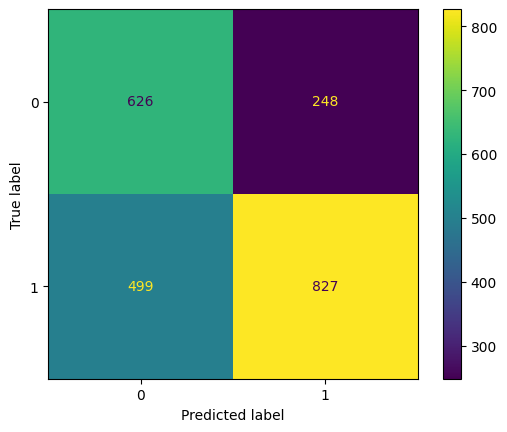

In [68]:
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [72]:
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

In [73]:
search_rf = RandomizedSearchCV(
    pipe_rf,
    param_rf,
    n_iter=5,
    cv=3,
    n_jobs=-1
)

search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` 

In [74]:
y_pred_rf_tuned= search_rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Best Params:", search_rf.best_params_)
print(classification_report(y_test, y_pred_rf))

Tuned RF Accuracy: 0.6718181818181819
Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 5}
              precision    recall  f1-score   support

           0       0.56      0.87      0.68       874
           1       0.87      0.54      0.66      1326

    accuracy                           0.67      2200
   macro avg       0.71      0.71      0.67      2200
weighted avg       0.74      0.67      0.67      2200



In [75]:
cm = confusion_matrix(y_test, y_pred_rf_tuned)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[797  77]
 [635 691]]


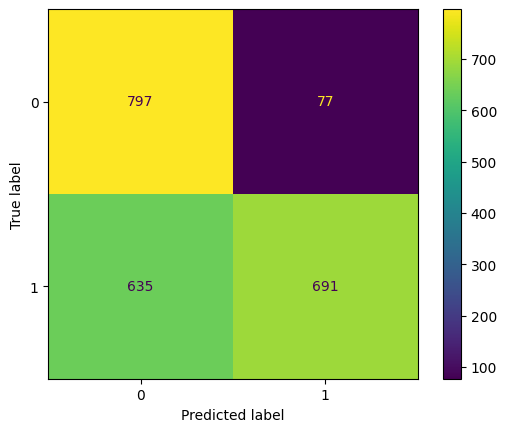

In [76]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [77]:
pipe_xgb = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss'))
])

pipe_xgb.fit(X_train, y_train)

y_pred_xgb = pipe_xgb.predict(X_test)

print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB Accuracy: 0.6522727272727272
              precision    recall  f1-score   support

           0       0.55      0.67      0.60       874
           1       0.75      0.64      0.69      1326

    accuracy                           0.65      2200
   macro avg       0.65      0.65      0.65      2200
weighted avg       0.67      0.65      0.66      2200



Confusion Matrix:
 [[584 290]
 [475 851]]


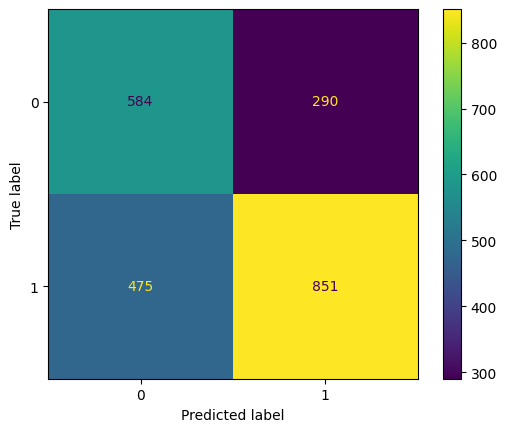

In [82]:
cm = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [79]:
param_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}


In [80]:
search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_xgb,
    n_iter=5,
    cv=3,
    n_jobs=-1
)

In [81]:
search_xgb.fit(X_train, y_train)

y_pred_xgb_tuned = search_xgb.predict(X_test)

In [83]:
print("XGB Tuned Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print(classification_report(y_test, y_pred_xgb_tuned))

XGB Tuned Accuracy: 0.6786363636363636
              precision    recall  f1-score   support

           0       0.56      0.83      0.67       874
           1       0.84      0.58      0.68      1326

    accuracy                           0.68      2200
   macro avg       0.70      0.70      0.68      2200
weighted avg       0.73      0.68      0.68      2200



Confusion Matrix:
 [[763 111]
 [611 715]]


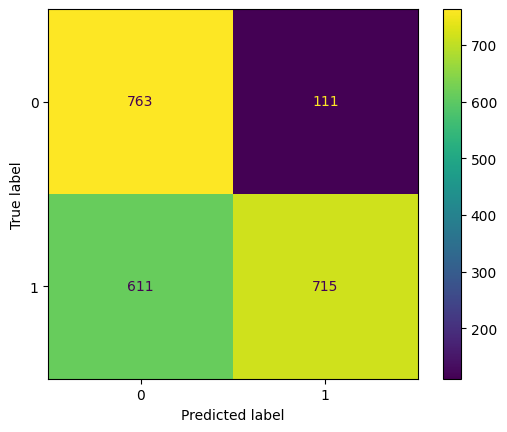

In [84]:
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [89]:
import os

os.makedirs("../models", exist_ok=True)

In [97]:
import pickle

with open("../models/best_lr.pkl", "wb") as f:
    pickle.dump(search_lr, f)

with open("../models/best_rf.pkl", "wb") as f:
    pickle.dump(search_rf, f)

with open("../models/best_xgb.pkl", "wb") as f:
    pickle.dump(search_xgb, f)